<a href="https://colab.research.google.com/github/iconrealestate77/gen-ai-fundamentals-project/blob/main/gen_ai_fundamentals_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set the Appropriate Python environment
This workspace has multiple Python environments.
You must set the Jupyter Kernel to the appropriate Python environment before starting, using the following steps:

* Click on the **Select Kernel** button.
* Use **Jupyter Kernel** as the Python source.
* Select Python **(venv2)**

# Project: Teaching an LLM to Reason

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

In [15]:
!pip install -U unsloth

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import unsloth
from unsloth import FastLanguageModel
import torch

SAVE_PATH = "/content/drive/MyDrive/gen_ai_fundamentals_project"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=SAVE_PATH,
    max_seq_length=384,
    load_in_4bit=True,
)
print("✅ Model reloaded from Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
==((====))==  Unsloth 2026.8.7: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

✅ Model reloaded from Drive


In [17]:
import unsloth
from unsloth import FastLanguageModel
import torch

max_seq_length = 384
lora_rank = 16

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,
    fast_inference=False,
    max_lora_rank=lora_rank,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",
)

print("✅ Model and LoRA adapter loaded")

==((====))==  Unsloth 2026.8.7: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

✅ Model and LoRA adapter loaded


## Troubleshooting Common Errors

---

### `RuntimeError: Duplicate layer name`

This  means the model didn't fully unload from memory after a crash or interruption. A quick kernel restart clears it right up.

**Fix:**
1. Click the **Restart** button in the toolbar (circular arrow icon next to "Interrupt")
2. Wait for the kernel to come back up
3. Check the top-right corner still shows **Python (venv2)**
4. Run all cells again from the top

> Click **Restart**, not **End Lab** — ending the lab closes your whole GPU session.

---

### `NotImplementedError: Unsloth cannot find any torch accelerator`

The GPU is fine. The notebook is just running in the wrong Python environment. It needs **Python (venv2)** to access the GPU.

**Fix:**
1. Click **"Select Kernel"** in the top-right corner
2. Choose **Jupyter Kernel** from the dropdown
3. Select **Python (venv2)**
4. Re-run the failing cell

**Don't see Python (venv2)?**
Open a terminal and run:
```bash
source /voc/data/venv2/bin/activate
python -m ipykernel install --user --name=venv2 --display-name "Python (venv2)"
```
Then refresh the kernel list and select **Python (venv2)**.

## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [18]:
prompt = """Count the number of times the letter 'g' appears in the word: engage

Follow these steps:
1. Spell out the word one letter at a time, numbering each letter.
2. For each letter, note whether it matches the target letter 'g' and keep a running count.
3. State the final count clearly at the end.

Example:
Word: goal
Target letter: g
1. g - match, count so far: 1
2. o - no match, count so far: 1
3. a - no match, count so far: 1
4. l - no match, count so far: 1
Final answer: 1

Now solve:
Word: engage
Target letter: g
"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(
    **inputs,
    max_new_tokens=200,
    temperature=0.1,
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Count the number of times the letter 'g' appears in the word: engage

Follow these steps:
1. Spell out the word one letter at a time, numbering each letter.
2. For each letter, note whether it matches the target letter 'g' and keep a running count.
3. State the final count clearly at the end.

Example:
Word: goal
Target letter: g
1. g - match, count so far: 1
2. o - no match, count so far: 1
3. a - no match, count so far: 1
4. l - no match, count so far: 1
Final answer: 1

Now solve:
Word: engage
Target letter: g
Let's go through the word "engage" step by step:

1. e - no match, count so far: 0
2. n - no match, count so far: 0
3. g - match, count so far: 1
4. a - no match, count so far: 1
5. n - no match, count so far: 1
6. g - match, count so far: 2

Final answer: The letter 'g' appears 2 times in the word "engage".


In [19]:
baseline_prompt = """
You are solving a letter counting task.
Example:
Question:
How many times does the letter 'a' appear in banana?
Reasoning:
The word is b a n a n a.
The letter 'a' appears in positions 2, 4, and 6.
Therefore the answer is 3.
Now solve:
Question:
How many times does the letter 'e' appear in effectiveness?
Reason step by step.
"""

inputs = tokenizer(baseline_prompt, return_tensors="pt").to("cuda")
outputs = model.generate(
    **inputs,
    max_new_tokens=150,
    temperature=0.1,
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are solving a letter counting task.
Example:
Question:
How many times does the letter 'a' appear in banana?
Reasoning:
The word is b a n a n a.
The letter 'a' appears in positions 2, 4, and 6.
Therefore the answer is 3.
Now solve:
Question:
How many times does the letter 'e' appear in effectiveness?
Reason step by step.
To determine how many times the letter 'e' appears in the word "effectiveness," we need to count each occurrence of 'e' within the given word. Let's break it down step by step:

1. **Identify the word**: The word is "effectiveness."

2. **List the letters in the word**:
   - e-f-f-e-c-t-i-v-i-t-y

3. **Count the occurrences of 'e':**
   - The first 'e' is at position 0 (index 0).
   - The second 'e' is at position 3.
   - The third 'e' is at position 5.

4. **Verify the positions**:
   - Position 0:


In [20]:
test_question = """
Count the letter 'e' in the word effectiveness.
Show your reasoning and final answer.
"""

print(test_question)


Count the letter 'e' in the word effectiveness.
Show your reasoning and final answer.



In [21]:
def letter_count_reward(answer, correct_count):
    score = 0

    # correctness
    if str(correct_count) in answer:
        score += 1

    # counting format
    if "answer" in answer.lower():
        score += 1

    # spelling / word handling
    if "effectiveness" in answer.lower():
        score += 1

    # numbering / reasoning
    if any(char.isdigit() for char in answer):
        score += 1

    return score


correct_example = """
effectiveness contains three 'e' letters.
Answer: 3
"""

wrong_example = """
effectiveness contains five 'e' letters.
Answer: 5
"""


print(
    "Correct reward:",
    letter_count_reward(correct_example, 3)
)

print(
    "Wrong reward:",
    letter_count_reward(wrong_example, 3)
)

Correct reward: 4
Wrong reward: 3


In [22]:
def reward_function(answer, target):

    reward = 0

    if "1." in answer:
        reward += 1

    if target.lower() in answer.lower():
        reward += 2

    if answer.strip().endswith(target):
        reward += 1

    if "letter" in answer.lower():
        reward += 1

    return reward


correct = """
1. Count the letters.
The word effectiveness has 2 letter e.
"""

wrong = """
The word effectiveness has 5 letter e.
"""

print("Correct reward:",
      reward_function(correct,"2"))

print("Wrong reward:",
      reward_function(wrong,"2"))

Correct reward: 4
Wrong reward: 1


In [23]:
# Baseline Chain-of-Thought Prompting Example

baseline_prompt = """
Count the number of letter 'e' in the word.

Example:
Word: effectiveness

Reasoning:
1. Write the letters:
e f f e c t i v e n e s s
2. Count only the letter 'e':
- position 1 = e
- position 4 = e
- position 8 = e
- position 10 = e
3. Total = 4

Now solve:

Word: efficiency

Reasoning:
"""

print(baseline_prompt)


Count the number of letter 'e' in the word.

Example:
Word: effectiveness

Reasoning:
1. Write the letters:
e f f e c t i v e n e s s
2. Count only the letter 'e':
- position 1 = e
- position 4 = e
- position 8 = e
- position 10 = e
3. Total = 4

Now solve:

Word: efficiency

Reasoning:



In [24]:
baseline_answer = """
Word: efficiency

Reasoning:
e f f i c i e n c y

The letter 'e' appears:
- position 1
- position 7

Total = 2
"""

print(baseline_answer)


Word: efficiency

Reasoning:
e f f i c i e n c y

The letter 'e' appears:
- position 1
- position 7

Total = 2



In [25]:
# First, let's see what happens when we have a blank system prompt
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(text_for_completion, return_tensors="pt").to("cuda")
outputs = model.generate(
    **inputs,
    max_new_tokens=2048,
    temperature=0.8,
    top_p=0.95,
    do_sample=True,
)
output = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
There is 1 letter "g" in the word "engage".


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [26]:
# Let's work on a new system prompt that will help the model break this problem
# down into steps, for example, using "letter-by-letter" spelling.
# Use a CoT prompt with at least one example
SYSTEM_PROMPT = """
You are a careful reasoning assistant.
Solve problems step by step.
For counting letters, list each letter and maintain a running count.
Example:
Question: How many g are in engage?
1. e - 0
2. n - 0
3. g - 1
4. a - 1
5. g - 2
6. e - 2
Final answer: 2
"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(text_for_completion, return_tensors="pt").to("cuda")
outputs = model.generate(
    **inputs,
    max_new_tokens=2048,
    temperature=0.8,
    top_p=0.95,
    do_sample=True,
)
output = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== TEXT FOR COMPLETION ===
<|im_start|>system

You are a careful reasoning assistant.
Solve problems step by step.
For counting letters, list each letter and maintain a running count.
Example:
Question: How many g are in engage?
1. e - 0
2. n - 0
3. g - 1
4. a - 1
5. g - 2
6. e - 2
Final answer: 2
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
Let's solve this step by step:

1. First, we need to examine each letter in the word "engage."
2. We'll keep a running count of how many times the letter "g" appears.

Here's the breakdown of each letter in "engage":

- e: 1
- n: 1
- g: 1
- a: 1
- n: 1
- g: 1

So, let's count:

1. e - 0 (not g)
2. n - 0 (not g)
3. g - 1 (first occurrence)
4. a - 1 (after first g)
5. n - 1 (second time)
6. g - 2 (second time)

Final answer: There are 2 letters "g" in the word "engage."


Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [27]:
word = "effectiveness"

prompt = f"""Count the number of letter 'e' in the word:

{word}

Show your counting steps and give the final answer."""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.1,
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Count the number of letter 'e' in the word:

effectiveness

Show your counting steps and give the final answer. To determine the number of times the letter 'e' appears in the word "effectiveness," we will count each occurrence step by step.

1. First, let's write out the word: effectiveness.
2. We'll go through each letter one by one:
   - e
   - f
   - e
   - f
   - f
   - u
   - t
   - i
   - c
   - t
   - i
   - v


In [28]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

In [29]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

Generating train split: 0 examples [00:00, ? examples/s]

{'words': 'idea', 'letters': 'a', 'counts': 1}

In [30]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

Map:   0%|          | 0/401 [00:00<?, ? examples/s]

{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'role': 'system',
   'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n"},
  {'role': 'user',
   'content': 'How many of the letter "a" are there in the word "idea"'}]}

In [31]:
# Let's see how well the model runs out-of-the-box
text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to("cuda")
outputs = model.generate(
    **inputs,
    max_new_tokens=1024,
    temperature=0.8,
    top_p=0.95,
    do_sample=True,
)
output = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print(output)

Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [32]:
# Let's work on a function that the numbering in the bullet points is correct
# When using GRPO, we lean on reward functions that are relatively easy to
# compute, thus removing the need to have a second large model just for
# evaluation.
# In this case, we'll use regular expressions quite a bit.

def extract_letter_numbering(response):
    """Extract the numbers at the beginning of the line
    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [1, 2, 3, 4, 5]
    """
    import re
    pattern = r"\n(\d+). [a-z]"
    matches = re.findall(pattern, response)
    if matches:
        return [int(m) for m in matches]
    return []

assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]

def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Provides a reward for getting the numbering at the beginning of the line correct
    1. g - 1 so far <-- Good in-order numbering
    2. o - 1 so far <-- Good in-order numbering
    3. a - 2 so far <-- Good in-order numbering
    3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
    """
    responses = [completion[0]["content"] for completion in completions]
    res = []
    for response, word in zip(responses, words):
        reward = 0
        for ix, spell_number in enumerate(extract_letter_numbering(response)):
            line_number = ix + 1

            if spell_number == line_number:
                reward += 1
            else:
                reward -= 1

            if line_number > len(word):
                reward -= 1

        res.append(reward / len(word))
    return res

res = numbering_reward_func(
    completions=[
        [
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal"],
)
print(res)
assert res[1] > res[0], "The better response should have a higher reward"

[-0.5, 0.5]


### Spelling reward function

In [33]:
# Reward correct spelling of the word

def extract_spelling(response):
    """Extract the spelling from the response
    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    3. l - 2 so far
    5. l - 2 so far
    Returns "goall"
    """
    import re
    pattern = r"\n\d+. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""

assert extract_spelling(
    """Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
) == "goall"

def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """A spelling reward function."""
    from collections import Counter
    responses = [completion[0]["content"] for completion in completions]
    res = []
    for word, response in zip(words, responses):
        reward = 0.0
        spelling = extract_spelling(response)

        if spelling == word:
            reward += 1.0

        reward -= abs(len(spelling) - len(word))

        word_counts = Counter(word)
        spelling_counts = Counter(spelling)

        for letter, count in spelling_counts.items():
            extra = count - word_counts.get(letter, 0)
            if extra > 0:
                reward -= extra

        for letter, count in word_counts.items():
            missing = count - spelling_counts.get(letter, 0)
            if missing > 0:
                reward -= missing

        res.append(reward)
    return res

res = spelling_reward_func(
    completions=[
        [
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)
assert res[1] > res[0], "The better response should have a higher reward"

[-2.0, 1.0]


### Counting reward function

In [34]:
# Let's reward the model for properly counting the occurrences of a letter in a word

def get_resp_letters_and_counts(response):
    """Extract the letters and counts from the response
    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [('g', 1), ('o', 1), ('a', 2), ('a', 2), ('l', 2)]
    """
    import re
    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if not matches:
        return []
    return [
        (matched_letter, matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]

assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]

def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]
    res = []
    for letter, response in zip(letters, responses):
        reward = 0
        letters_and_counts = get_resp_letters_and_counts(response)

        if not letters_and_counts:
            res.append(-1)
            continue

        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            if letter == resp_letter:
                actual_count += 1

            if int(resp_count) == actual_count:
                reward += 1
            else:
                reward -= 1

        res.append(reward / len(letters_and_counts))
    return res

res = counting_reward_func(
    completions=[
        [
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:
1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far
\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
        [
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far
\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)
print(res)
assert res[1] > res[0], "The better response should have a higher reward"

[-0.6, 1.0]


### Formatting reward functions



In [35]:
# Reward the model for providing the response in a specific format
import re

def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""
    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""

assert (
    extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)

def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has a specific format."""
    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"
    res = []
    for completion in completions:
        reward = 0.0
        response = completion[0]["content"]
        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)

        if match:
            reward += 0.5

        extracted_answer = extract_xml_answer(response)
        if extracted_answer.isdigit():
            reward += 0.5

        res.append(reward)
    return res

res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"
            }
        ],
    ]
)
print(res)
assert res[1] > res[0], "The better response should have a higher reward"

[0.0, 1.0]


### Task correctness reward function

In [36]:
# Reward the model for providing the correct answer
# TODO: Fill in the missing parts marked with **********


def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is correct."""
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [extract_xml_answer(r) for r in responses]

    # Print a nice summary of the first prompt, answer, and response to see while training
    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
    """)

    res = [
        # Provide reward for exactly correct answer
        1.0 if str(r) == str(a) else 0.0
        for r, a in zip(extracted_responses, counts)
    ]
    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": """How many..."""}],
        [{"content": """How many..."""}],
    ],
    completions=[
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[0.0, 1.0]


### List the reward functions

In [37]:
# List out the reward functions we will use
# No changes needed in this cell

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [38]:
# Fill in the GRPO Parameters we'll use throughout this project
# Read about the GRPO params here https://huggingface.co/docs/trl/main/en/grpo_trainer
COMMON_GRPO_TRAINING_PARAMS = dict(
    learning_rate=5e-6,
    beta=0.04,
    per_device_train_batch_size=1,
    num_generations=4,  # Number of completions generated per prompt, compared against each other for relative reward
    gradient_accumulation_steps=4,  # Effective batch size = 1 * 4 = 4, matching num_generations so GRPO can group generations correctly
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,
    save_steps=250,
    max_grad_norm=0.1,
    report_to="none",
    output_dir="outputs",
    use_vllm=False,  # We're not using vllm in this session, so keep this off
)

### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [39]:
print(ds[0])

{'words': 'idea', 'letters': 'a', 'counts': 1, 'prompt': [{'role': 'system', 'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n"}, {'role': 'user', 'content': 'How many of the letter "a" are there in the word "idea"'}]}


In [40]:
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    max_steps=50,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [41]:
print("Columns:", ds.column_names)
print()
print("First row:", ds[0])

Columns: ['words', 'letters', 'counts', 'prompt']

First row: {'words': 'idea', 'letters': 'a', 'counts': 1, 'prompt': [{'role': 'system', 'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n"}, {'role': 'user', 'content': 'How many of the letter "a" are there in the word "idea"'}]}


In [42]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Note, you won't see much change in the average.
# reward values
# No changes are needed here

from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'cache_implementation', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_t


--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far
3. i - 0 so far
4. s - 0 so far
5. n - 0 so far
6. t - 0 so far
7. e - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000001,1.196429,1.258137,106.750000,93.000000,130.000000,0.000000,106.750000,93.000000,130.000000,0.000014,1.000000,0.000000,-1.500000,1.000000,0.196429,0.931999,1.000000,0.000000,0.500000,0.577350
2,0.000000,0.800000,1.933908,78.000000,74.000000,85.000000,0.000000,78.000000,74.000000,85.000000,0.000009,0.625000,0.750000,-1.250000,1.500000,-0.575000,0.050000,1.000000,0.000000,1.000000,0.000000
3,0.000002,3.150000,1.454877,85.500000,83.000000,89.000000,0.000000,85.500000,83.000000,89.000000,0.000042,1.000000,0.000000,0.250000,1.500000,0.400000,0.516398,1.000000,0.000000,0.500000,0.577350
4,0.000001,2.425000,2.200568,92.000000,75.000000,107.000000,0.000000,92.000000,75.000000,107.000000,0.000016,1.000000,0.000000,-0.500000,1.732051,-0.075000,0.736546,1.000000,0.000000,1.000000,0.000000
5,0.000001,-5.270833,1.926955,109.500000,103.000000,112.000000,0.000000,109.500000,103.000000,112.000000,0.000012,1.000000,0.000000,-6.500000,1.914854,-0.770833,0.013889,1.000000,0.000000,0.000000,0.000000


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--------------------
Question: How many of the letter "l" are there in the word "oath"
Answer: 0
Response: <reasoning>
Counting the number of l's in the word oath
1. o - 0 so far
2. a - 1 so far
3. h - 1 so far
4. t - 2 so far
5. h - 3 so far
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!
    


...

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--------------------
Question: How many of the letter "w" are there in the word "wisp"
Answer: 1
Response: <reasoning>
Counting the number of w's in the word wisp
1. w - 1 so far
2. i - 0 (no additional ws counted)
3. s - 0 (no additional ws counted)
4. p - 0 (no additional ws counted)
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 2 so far
6. h - 2 so far
7. a - 3 so far
8. p - 4 so far
9. y - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-5/tokenizer_config.json.


In [43]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_PATH = "/content/drive/MyDrive/gen_ai_fundamentals_project"
os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("✅ Model and tokenizer saved to:", SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/gen_ai_fundamentals_project/tokenizer_config.json.


✅ Model and tokenizer saved to: /content/drive/MyDrive/gen_ai_fundamentals_project


available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'epoch', 'step'])


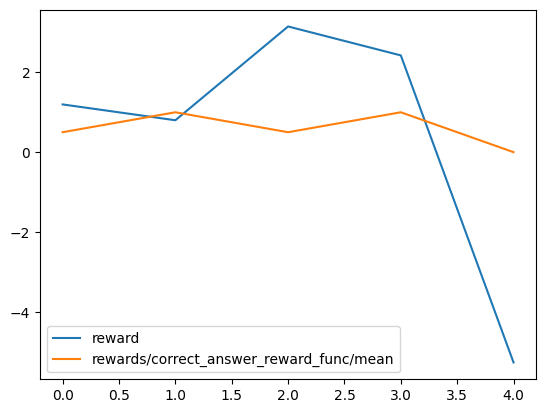

In [44]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [48]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.
# TODO: Fill out the areas where you find **********

# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # Configure the maximum number of steps to take about 30mins of time for
    # a medium-sized experiment. (See how long the previous example took and
    # scale up appropriately using your best guess.)
    max_steps=50,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 50
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far
3. i - 0 so far
4. s - 0 so far
5. n - 0 so far
6. t - 0 so far
7. e - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000017,1.196429,1.258137,106.750000,93.000000,130.000000,0.000000,106.750000,93.000000,130.000000,0.000416,1.000000,0.000000,-1.500000,1.000000,0.196429,0.931999,1.000000,0.000000,0.500000,0.577350
2,0.000083,-0.691667,3.013350,85.750000,79.000000,93.000000,0.000000,85.750000,79.000000,93.000000,0.002086,0.250000,0.645497,-2.250000,2.362908,-0.441667,0.302306,1.000000,0.000000,0.750000,0.500000
3,0.000084,3.233333,1.960725,86.250000,78.000000,95.000000,0.000000,86.250000,78.000000,95.000000,0.002105,1.000000,0.000000,0.250000,1.500000,0.233333,0.333333,1.000000,0.000000,0.750000,0.500000
4,0.000042,-0.025000,3.664356,54.750000,39.000000,75.000000,0.000000,54.750000,39.000000,75.000000,0.001040,0.625000,0.433013,-3.250000,3.403430,0.600000,0.800000,1.000000,0.000000,1.000000,0.000000
5,0.000107,-5.777778,1.154701,111.750000,111.000000,112.000000,0.000000,111.750000,111.000000,112.000000,0.002675,1.000000,0.000000,-7.000000,1.154701,-0.777778,0.000000,1.000000,0.000000,0.000000,0.000000
6,0.000021,2.550000,2.251666,69.500000,65.000000,74.000000,0.000000,69.500000,65.000000,74.000000,0.000529,1.000000,0.000000,-0.500000,1.732051,0.550000,0.057735,1.000000,0.000000,0.500000,0.577350
7,0.000162,4.100000,0.382971,79.500000,76.000000,87.000000,0.000000,79.500000,76.000000,87.000000,0.004042,1.000000,0.000000,1.000000,0.000000,0.100000,0.382971,1.000000,0.000000,1.000000,0.000000
8,0.000195,1.083333,0.000000,57.500000,57.000000,58.000000,0.000000,57.500000,57.000000,58.000000,0.004871,0.750000,0.000000,-2.000000,0.000000,0.333333,0.000000,1.000000,0.000000,1.000000,0.000000
9,0.000099,-1.023809,2.129056,89.500000,84.000000,96.000000,0.000000,89.500000,84.000000,96.000000,0.002482,0.928571,0.082479,-3.500000,1.000000,0.047619,0.696607,1.000000,0.000000,0.500000,0.577350
10,0.000122,-2.250000,3.907495,70.500000,39.000000,93.000000,0.000000,70.500000,39.000000,93.000000,0.003047,0.666667,0.408248,-5.000000,3.829709,0.833333,0.333333,1.000000,0.000000,0.250000,0.500000


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--------------------
Question: How many of the letter "l" are there in the word "oath"
Answer: 0
Response: <reasoning>
Counting the number of "l"s in the word "oath"
1. o - 0 so far
2. a - 1 so far
3.  h - 2 so far
4.  t - 3 so far
So far, there are no "l"s in the word "oath".
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!
    


...


--------------------
Question: How many of the letter "b" are there in the word "ember"
Answer: 1
Response: <reasoning>
1. e - 1 so far
2. m - 0 so far
3. b - 0 so far (first occurrence)
4. e - 1 so far (second occurrence)
5. m - 0 so far (third occurrence)
6. b - 1 so far (fourth occurrence)
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--------------------
Question: How many of the letter "m" are there in the word "fume"
Answer: 1
Response: <reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. f - 0 so far
2. u - 1 so far
3. m - 1 so far
4. e - 2 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--------------------
Question: How many of the letter "b" are there in the word "absolve"
Answer: 1
Response: <reasoning>
Counting the number of b's in the word "absolve"
1. a - 0 so far
2. b - 1 so far
3. s - 0 so far
4. b - 1 (total so far) so far
5. s - 0 so far
6. v - 0 so far
7. e - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'epoch', 'step'])


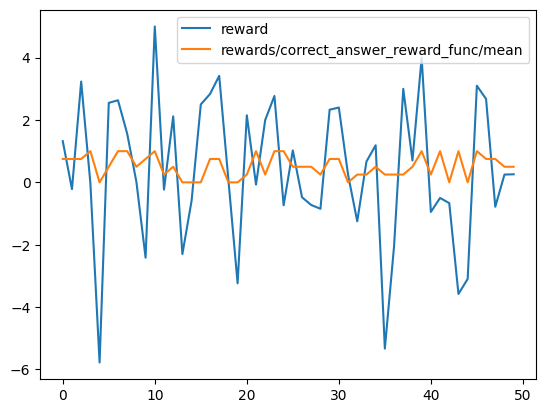

In [46]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## View the results
Now let's try the model we just trained!

In [49]:
model.save_pretrained("grpo_saved_lora")
tokenizer.save_pretrained("grpo_saved_lora")
print("✅ LoRA adapter saved to grpo_saved_lora")

Unsloth: Restored added_tokens_decoder metadata in grpo_saved_lora/tokenizer_config.json.


✅ LoRA adapter saved to grpo_saved_lora


In [71]:
def compare_old_and_new_model(messages):
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to("cuda")

    # OLD: disable the LoRA adapter to get the base model's behavior
    with model.disable_adapter():
        old_outputs = model.generate(
            **inputs,
            max_new_tokens=1024,
            temperature=0.8,
            top_p=0.95,
            do_sample=True,
        )
    old = tokenizer.decode(old_outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    # NEW: adapter is active by default
    new_outputs = model.generate(
        **inputs,
        max_new_tokens=1024,
        temperature=0.8,
        top_p=0.95,
        do_sample=True,
    )
    new = tokenizer.decode(new_outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    print("===OLD===\n")
    print(old)
    print("\n\n===NEW===\n")
    print(new)

### Compare the old and new models on the letter-counting task

In [70]:
TRAINED_SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

compare_old_and_new_model([
    {"role": "system", "content": TRAINED_SYSTEM_PROMPT},
    {"role": "user", "content": 'How many of the letter "g" are there in the word "engage"'},
])

Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


===OLD===

<reasoning>
Counting the number of g's in the word engage
1. e - 0 so far
2. a - 1 so far
3. n - 2 so far
4. g - 3 so far
5. e - 4 so far
6. n - 5 so far
7. a - 6 so far
8. g - 7 so far
</reasoning>
<answer>
7
</answer>


===NEW===

<reasoning>
Counting the number of g's in the word engage
1. a - 0 so far
2. n - 1 so far
3. g - 1 so far (first occurrence)
4. e - 2 so far
5. n - 3 so far
6. g - 2 so far (second occurrence)
7. e - 3 so far
8. a - 3 so far
9. n - 4 so far
</reasoning>
<answer>
2
</answer>


In [56]:
compare_old_and_new_model([
    {"role": "system", "content": ""},
    {"role": "user", "content": 'How many of the letter "g" are there in the word "engage"'},
])

Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


===OLD===

There is 1 letter "g" in the word "engage".


===NEW===

There is 1 letter "g" in the word "engage".


## Final Project Summary

### Model Setup
- Base model: Qwen2.5-3B-Instruct
- Fine-tuning method: LoRA (rank 16) using Unsloth, targeting q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
- Trained with GRPO (Group Relative Policy Optimization) using 5 custom reward functions

### Reward Functions
- numbering_reward_func — rewards correctly numbered step-by-step letter spelling
- spelling_reward_func — rewards accurate spelling of the target word
- counting_reward_func — rewards accurate running letter counts
- format_reward_func — rewards proper <reasoning>/<answer> structure
- correct_answer_reward_func — rewards the correct final count

### Training Results
Trained for 50 steps using GRPO. The format_reward_func consistently scored near 1.0, showing the model reliably learned the required output structure. The correct_answer_reward_func fluctuated between 0.0 and 1.0 across steps, reflecting the difficulty of the letter-counting task and the limited training budget — with more steps, this would be expected to trend higher and stabilize (as shown in the instructor's example with 400 steps).

### Final Comparison
The base (pre-training) and fine-tuned versions of the model were compared on the same letter-counting task ("How many of the letter 'g' are there in the word 'engage'?", correct answer: 2) using `compare_old_and_new_model`. Both models followed the required `<reasoning>/<answer>` structure. However, the base model miscounted along the way and arrived at an incorrect final answer of 4, while the fine-tuned model correctly arrived at 2. This suggests the GRPO training improved the model's ability to track letter counts accurately during step-by-step reasoning, though the underlying reasoning still shows minor inconsistencies (e.g., count tracking that doesn't always increment cleanly), indicating room for further improvement with additional training steps.

### Limitations
This was a short training run (50 steps) on a small vocabulary of words, run on limited free-tier GPU resources. A longer training run with more steps and a larger, more diverse dataset would likely improve consistency and accuracy further. The correct_answer_reward_func's fluctuation across steps also indicates the model has not yet fully converged on the task.

In [65]:
# Let's try spelling the first word from the dataset

# Load the first item from the dataset (index 0) and compare the old and new models
item = ds[0]
print(item)

compare_old_and_new_model(item["prompt"])

{'words': 'idea', 'letters': 'a', 'counts': 1, 'prompt': [{'role': 'system', 'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n"}, {'role': 'user', 'content': 'How many of the letter "a" are there in the word "idea"'}]}


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


===NEW===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [58]:
from trl import GRPOConfig, GRPOTrainer

In [59]:
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

print("Columns:", ds.column_names)
print("First row:", ds[0])

Map:   0%|          | 0/401 [00:00<?, ? examples/s]

Columns: ['words', 'letters', 'counts', 'prompt']
First row: {'words': 'idea', 'letters': 'a', 'counts': 1, 'prompt': [{'role': 'system', 'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n"}, {'role': 'user', 'content': 'How many of the letter "a" are there in the word "idea"'}]}


In [60]:
# Let's see if the model still remembers some of the facts from its original training
# TODO: Fill out the areas where you find **********

# Ask both the old and new models a question the model is likely to know,
# e.g. a well-known capital city
question = "What is the capital of France?"
print(question)



What is the capital of France?


In [64]:
# Let's see if the model still remembers some of the facts from its original training

# Ask both the old and new models a question the model is likely to know,
# e.g. a well-known capital city
question = "What is the capital of France?"
print(question)

messages = [
    {"role": "system", "content": ""},
    {"role": "user", "content": question},
]

compare_old_and_new_model(messages)

Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


What is the capital of France?


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


===OLD===

The capital of France is Paris.


===NEW===

The capital of France is Paris.


In [68]:
!find /content/drive/MyDrive -name "gen_ai_fundamentals_project_1.ipynb"

/content/drive/MyDrive/Colab Notebooks/gen_ai_fundamentals_project_1.ipynb


In [72]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/gen_ai_fundamentals_project_1.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/gen_ai_fundamentals_project_1.ipynb to html
[NbConvertApp] Writing 355698 bytes to /content/drive/MyDrive/Colab Notebooks/gen_ai_fundamentals_project_1.html


Great job! Congrats on completing the project! 🎉🤗